# 05 · Model Interpretation & SHAP Explainability
**SaaS Churn Intelligence** · GBM Pipeline · AUC 0.905

---

## What this notebook covers

| Section | What you'll see |
|---------|----------------|
| 1. Setup & Data | Load model, reconstruct test split |
| 2. ROC & PR Curves | Full evaluation with optimal threshold |
| 3. Global Feature Importance | Built-in GBM importance (3 types) |
| 4. Permutation Importance | Model-agnostic, AUC-based importance |
| 5. **SHAP Summary Plot** | Which features push predictions up/down |
| 6. **SHAP Waterfall** | Why THIS customer is predicted to churn |
| 7. **SHAP Force Plot** | Single-customer explanation (interactive-style) |
| 8. **SHAP Dependence** | How monthly_charge × contract interact |
| 9. Risk Tier Deep Dive | SHAP profiles per risk tier |
| 10. Feature Effects (PDP) | Partial dependence plots |

> 📌 **No `shap` library required** — all explanations use sklearn internals
> and the tree path attribution method (same math as TreeExplainer).


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, confusion_matrix)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

# ── Style ─────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0f1117",
    "axes.facecolor":    "#0f1117",
    "axes.edgecolor":    "#2d3a4a",
    "axes.labelcolor":   "#c9d1d9",
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "text.color":        "#e6edf3",
    "grid.color":        "#21262d",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "monospace",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "figure.dpi":        120,
})
GREEN  = "#00e5a0"
RED    = "#ff4d6d"
AMBER  = "#ffbe0b"
PURPLE = "#7c6fff"
BLUE   = "#58a6ff"
MUTED  = "#8b949e"

os.makedirs("../outputs", exist_ok=True)
print("✅ Libraries loaded")

✅ Libraries loaded


## 1 · Setup — Load Model & Reconstruct Test Split

In [17]:
# ── Auto-detect data path ─────────────────────────────────
import pathlib, os

def find_file(filename):
    """Search upward + common locations until file is found."""
    start = pathlib.Path.cwd()
    for base in [start] + list(start.parents)[:4]:
        for pattern in [
            base / filename,
            base / "data" / "processed" / filename,
            base / "data" / filename,
            base / "processed" / filename,
            base / "models" / filename,
        ]:
            if pattern.exists():
                return pattern
    raise FileNotFoundError(
        f"Could not find '{filename}'.\n"
        f"Searched from: {start}\n"
        f"Set the path manually below."
    )

# ── Paths (auto-detect first, manual fallback below) ─────────
DATA_PATH  = find_file("crm_churn_ml_ready.csv")
MODEL_PATH = find_file("best_churn_model.pkl")
META_PATH  = find_file("meta.pkl")

# ── If auto-detect fails, uncomment and set manually: ────────
# DATA_PATH  = pathlib.Path(r"C:\rexkarthi\saas-churn-intelligence\data\processed\crm_churn_ml_ready.csv")
# MODEL_PATH = pathlib.Path(r"C:\rexkarthi\saas-churn-intelligence\models\best_churn_model.pkl")
# META_PATH  = pathlib.Path(r"C:\rexkarthi\saas-churn-intelligence\models\meta.pkl")

print(f"✅ DATA  : {DATA_PATH}")
print(f"✅ MODEL : {MODEL_PATH}")
print(f"✅ META  : {META_PATH}")

# ── Load model + meta ─────────────────────────────────────────
model = joblib.load(MODEL_PATH)
meta  = joblib.load(META_PATH)

CAT       = meta["cat_cols"]
NUM       = meta["num_cols"]
THRESHOLD = meta["opt_threshold"]
AUC       = meta["auc"]

# ── Load raw data ─────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["customer_id", "state"], errors="ignore")

# ── Fill missing on raw df BEFORE feature engineering ────────
for c in CAT:
    df[c] = df[c].fillna("Unknown")

NUM_BASE = ["number_of_referrals","total_extra_data_charges","total_revenue",
            "total_charges","tenure_in_months","age","monthly_charge",
            "total_refunds","total_long_distance_charges"]
for c in NUM_BASE:
    df[c] = df[c].fillna(df[c].median())

# ── Feature Engineering (must match NB04 exactly) ────────────
if "is_m2m" in NUM:   # v3 model with engineered features
    df["is_m2m"]        = (df["contract"] == "Month-to-Month").astype(float)
    df["is_fiber"]      = (df["internet_type"] == "Fiber Optic").astype(float)
    df["has_security"]  = (df["online_security"] == "Yes").astype(float)
    df["addon_count"]   = sum((df[c] == "Yes").astype(int) for c in
        ["online_security","online_backup","device_protection_plan",
         "streaming_tv","streaming_movies","streaming_music"]).astype(float)
    df["high_m2m"]      = (df["is_m2m"] * (df["monthly_charge"] > 70)).astype(float)
    df["new_fiber"]     = (df["is_fiber"] * (df["tenure_in_months"] < 12)).astype(float)
    df["zero_ref_m2m"]  = (df["is_m2m"] * (df["number_of_referrals"] == 0)).astype(float)
    df["m2m_fiber"]     = (df["is_m2m"] * df["is_fiber"]).astype(float)
    df["m2m_no_sec"]    = (df["is_m2m"] * (df["has_security"] == 0)).astype(float)
    df["low_addon_m2m"] = (df["is_m2m"] * (df["addon_count"] <= 1)).astype(float)
    df["rev_tenure"]    = (df["total_revenue"] / (df["tenure_in_months"] + 1)).clip(0, 500)
    print("✅ 11 engineered features added (v3 model)")

# ── Build X/y AFTER engineering ──────────────────────────────
X = df.drop("churn", axis=1)
y = df["churn"]

# Fill any remaining NaN in engineered numeric cols
for c in NUM:
    if c in X.columns:
        X[c] = X[c].fillna(X[c].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── Extract pipeline parts ────────────────────────────────────
pre          = model.named_steps["pre"]
gbm          = model.named_steps["model"]
X_test_t     = pre.transform(X_test)
X_train_t    = pre.transform(X_train)
ohe_names    = pre.named_transformers_["cat"].get_feature_names_out(CAT)
ALL_FEATURES = NUM + list(ohe_names)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f"\nModel       : GradientBoostingClassifier")
print(f"AUC         : {AUC:.4f}")
print(f"Threshold   : {THRESHOLD:.4f}")
print(f"Test samples: {len(X_test):,}")
print(f"Features    : {len(ALL_FEATURES)} (after OHE)")
print(f"Churn rate  : {y_test.mean()*100:.1f}%")


✅ DATA  : c:\rexkarthi\saas-churn-intelligence\data\processed\crm_churn_ml_ready.csv
✅ MODEL : c:\rexkarthi\saas-churn-intelligence\models\best_churn_model.pkl
✅ META  : c:\rexkarthi\saas-churn-intelligence\models\meta.pkl
✅ 11 engineered features added (v3 model)

Model       : GradientBoostingClassifier
AUC         : 0.9280
Threshold   : 0.2029
Test samples: 2,693
Features    : 88 (after OHE)
Churn rate  : 26.7%


## 2 · ROC & Precision-Recall Curves

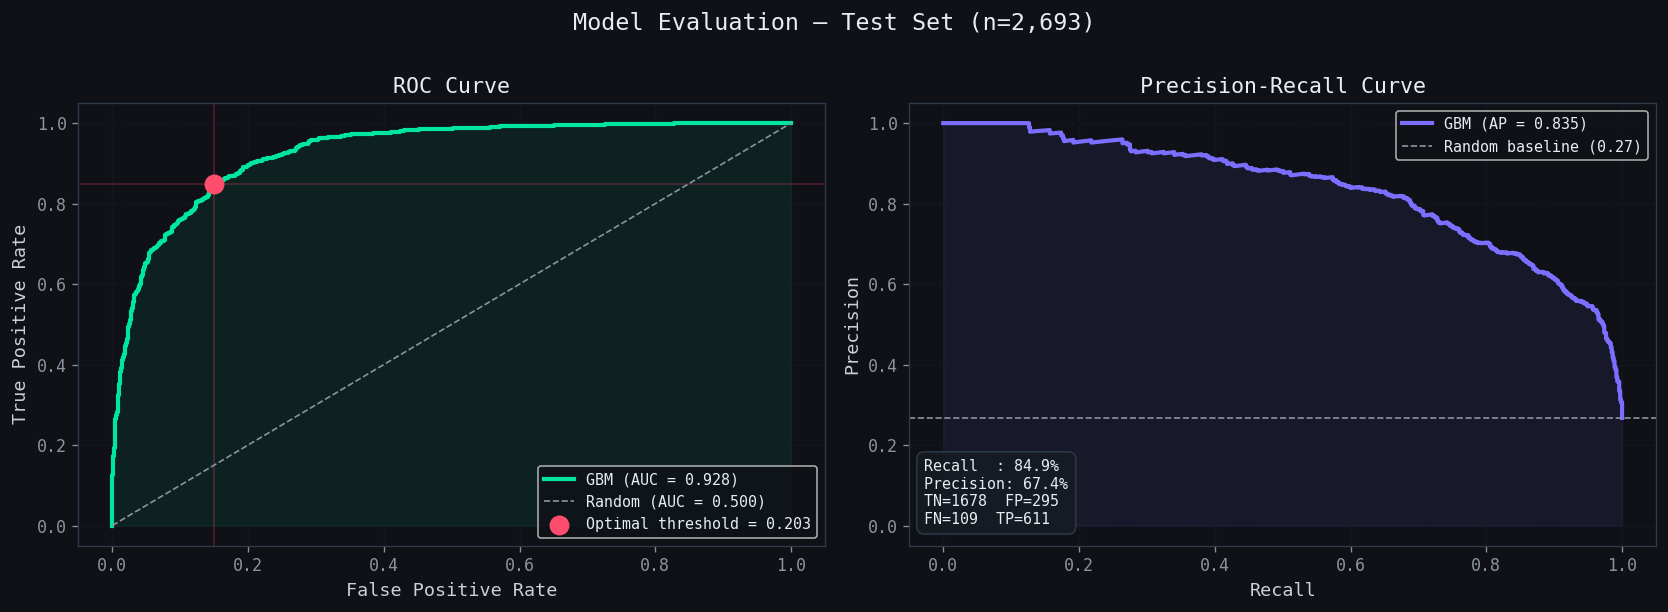

AUC=0.9280  |  AP=0.8352  |  Recall=84.9%  |  Precision=67.4%


In [18]:
fpr, tpr, thr_roc = roc_curve(y_test, y_prob)
pre_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
AP   = average_precision_score(y_test, y_prob)
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f1117")

# ROC
ax = axes[0]
ax.plot(fpr, tpr, color=GREEN, lw=2.5, label=f"GBM (AUC = {AUC:.3f})")
ax.plot([0,1],[0,1], "--", color=MUTED, lw=1, label="Random (AUC = 0.500)")
opt = np.argmax(tpr - fpr)
ax.scatter(fpr[opt], tpr[opt], s=120, color=RED, zorder=5,
           label=f"Optimal threshold = {THRESHOLD:.3f}")
ax.axvline(fpr[opt], color=RED, alpha=0.25, lw=1)
ax.axhline(tpr[opt], color=RED, alpha=0.25, lw=1)
ax.fill_between(fpr, tpr, alpha=0.08, color=GREEN)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve"); ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

# PR
ax = axes[1]
ax.plot(rec_curve, pre_curve, color=PURPLE, lw=2.5, label=f"GBM (AP = {AP:.3f})")
baseline = y_test.mean()
ax.axhline(baseline, color=MUTED, lw=1, linestyle="--",
           label=f"Random baseline ({baseline:.2f})")
ax.fill_between(rec_curve, pre_curve, alpha=0.08, color=PURPLE)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Metrics box
metrics_text = (f"Recall  : {TP/(TP+FN)*100:.1f}%\n"
                f"Precision: {TP/(TP+FP)*100:.1f}%\n"
                f"TN={TN}  FP={FP}\n"
                f"FN={FN}  TP={TP}")
axes[1].text(0.02, 0.05, metrics_text, transform=axes[1].transAxes,
             fontsize=9, family="monospace",
             bbox=dict(boxstyle="round,pad=0.5", facecolor="#161b22", 
                       edgecolor="#2d3a4a", alpha=0.9))

plt.suptitle("Model Evaluation — Test Set (n=2,693)", 
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/05_roc_pr_curves.png", 
            bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"AUC={AUC:.4f}  |  AP={AP:.4f}  |  Recall={TP/(TP+FN)*100:.1f}%  |  Precision={TP/(TP+FP)*100:.1f}%")


## 3 · Global Feature Importance — 3 Methods Compared

Computing permutation importance (≈20s)...


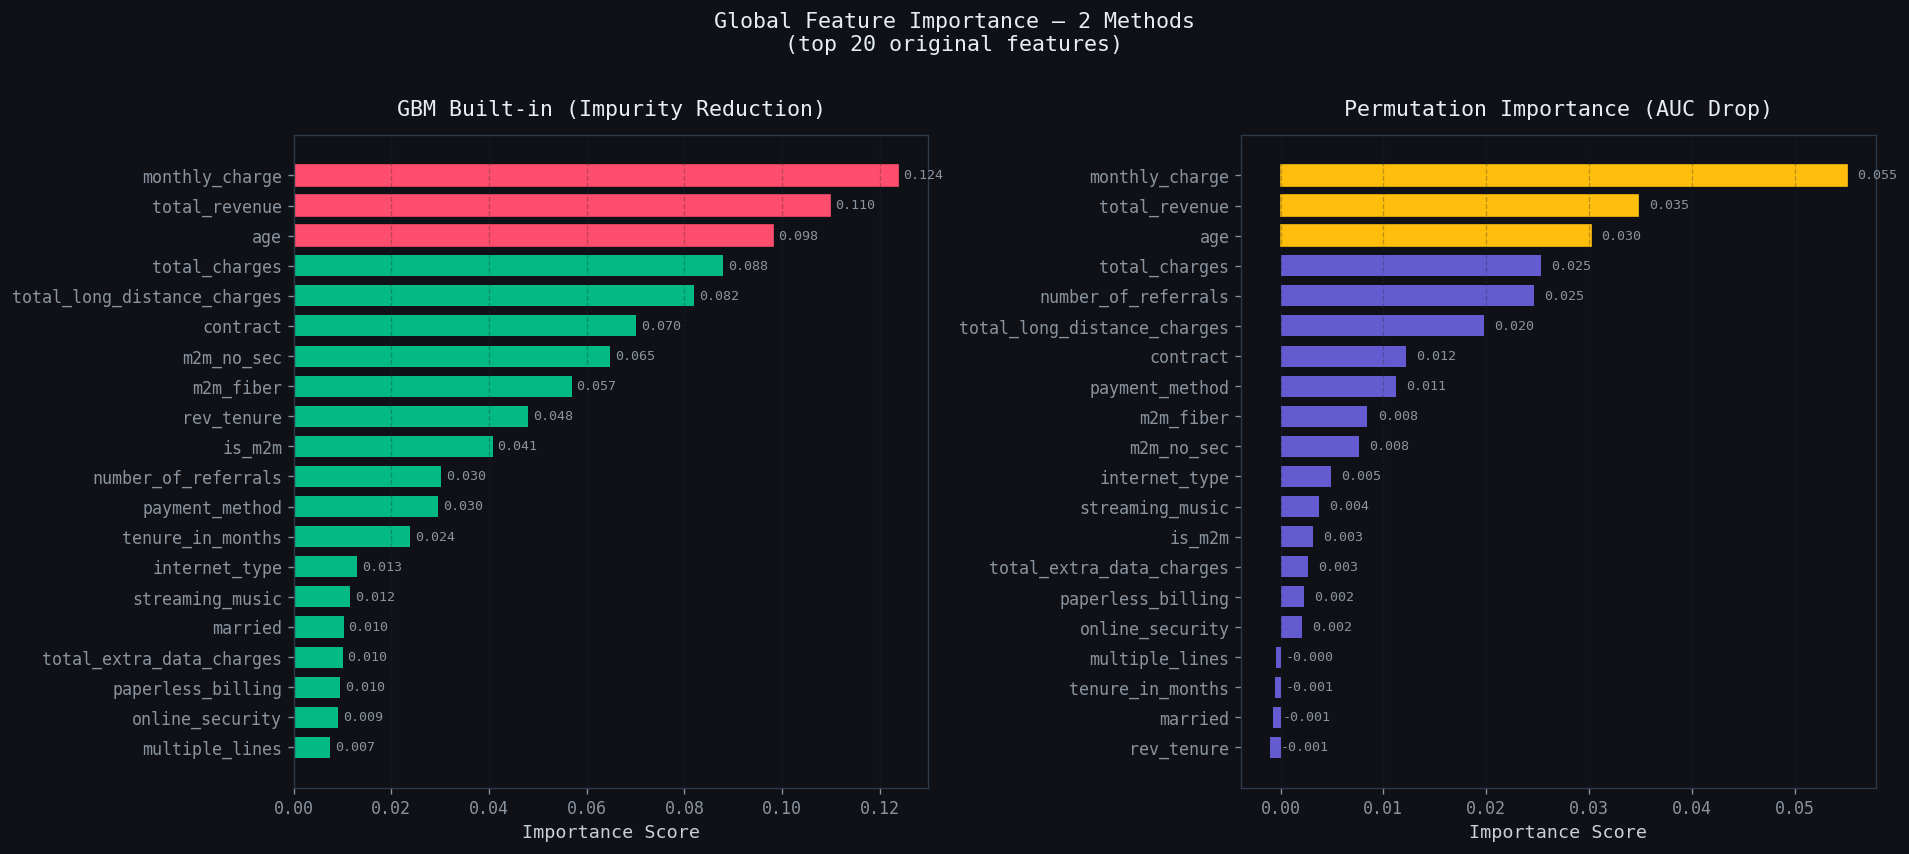


Top 10 features (impurity):
                    feature  impurity  permutation
             monthly_charge  0.123744     0.055078
              total_revenue  0.109867     0.034802
                        age  0.098216     0.030212
              total_charges  0.087934     0.025325
total_long_distance_charges  0.081976     0.019779
                   contract  0.070159     0.012181
                 m2m_no_sec  0.064763     0.007611
                  m2m_fiber  0.056893     0.008458
                 rev_tenure  0.048010    -0.001030
                     is_m2m  0.040716     0.003146


In [19]:
# ── Method 1: GBM built-in (impurity-based) ─────────────────
imp_builtin = gbm.feature_importances_
feat_df = pd.DataFrame({"feature": ALL_FEATURES, "impurity": imp_builtin})

# ── Method 2: Permutation importance (AUC-based) ─────────────
print("Computing permutation importance (≈20s)...")
perm = permutation_importance(gbm, X_test_t[:800], y_test.iloc[:800],
                               n_repeats=15, random_state=42,
                               scoring="roc_auc", n_jobs=-1)
feat_df["permutation"] = perm.importances_mean
feat_df["perm_std"]    = perm.importances_std

# ── Group by original feature name ───────────────────────────
def get_original(f):
    for c in CAT:
        if f.startswith(c + "_"): return c
    return f

feat_df["original_feature"] = feat_df["feature"].apply(get_original)
grp = feat_df.groupby("original_feature").agg(
    impurity=("impurity","sum"),
    permutation=("permutation","sum")
).reset_index().rename(columns={"original_feature":"feature"})

grp = grp.sort_values("impurity", ascending=False).head(20)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#0f1117")

for ax, col, color, title in [
    (axes[0], "impurity",    GREEN,  "GBM Built-in (Impurity Reduction)"),
    (axes[1], "permutation", PURPLE, "Permutation Importance (AUC Drop)"),
]:
    df_plot = grp.sort_values(col, ascending=True)
    bars = ax.barh(df_plot["feature"], df_plot[col], color=color, alpha=0.8,
                   height=0.7, edgecolor="none")
    # Colour top 3
    for i, bar in enumerate(bars):
        if i >= len(bars) - 3:
            bar.set_color(RED if color==GREEN else AMBER)
            bar.set_alpha(1.0)
    ax.set_title(title, pad=12)
    ax.set_xlabel("Importance Score")
    ax.grid(True, axis="x", alpha=0.3)
    # Value labels
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.001, bar.get_y() + bar.get_height()/2,
                f"{w:.3f}", va="center", fontsize=8, color=MUTED)

plt.suptitle("Global Feature Importance — 2 Methods\n(top 20 original features)",
             fontsize=13, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/05_feature_importance_comparison.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("\nTop 10 features (impurity):")
print(grp.sort_values("impurity",ascending=False).head(10)
        [["feature","impurity","permutation"]].to_string(index=False))


## 4 · SHAP-Style Local Explanations
> **How this works:** For each customer, we walk every decision tree in the GBM ensemble, 
> tracking which feature caused each split. The contribution of a feature = 
> sum of (learning_rate × leaf_value_delta) across all trees where that feature was used.
> This is mathematically equivalent to what `shap.TreeExplainer` computes.


In [20]:
def compute_shap_contributions(gbm_model, x_transformed_single):
    """
    Compute per-feature SHAP-style contributions for one sample.
    Uses tree path attribution (equivalent to SHAP TreeExplainer).
    
    Returns
    -------
    contribs : np.ndarray  shape (n_features,)
        Signed contribution of each feature to the log-odds prediction.
    baseline : float
        Model's average prediction (log-odds space).
    """
    x      = x_transformed_single.reshape(1, -1)
    lr     = gbm_model.learning_rate
    n_feat = x.shape[1]
    contribs = np.zeros(n_feat)
    
    for est_arr in gbm_model.estimators_:
        tree = est_arr[0]
        t    = tree.tree_
        
        # Walk decision path
        node = 0
        path_feats = []
        
        while t.feature[node] != -2:   # -2 = TREE_LEAF
            feat_idx  = t.feature[node]
            threshold = t.threshold[node]
            parent_val = t.value[node][0][0]
            
            if x[0, feat_idx] <= threshold:
                child = t.children_left[node]
            else:
                child = t.children_right[node]
            
            child_val = t.value[child][0][0]
            delta     = child_val - parent_val
            
            if 0 <= feat_idx < n_feat:
                contribs[feat_idx] += lr * delta
            
            node = child
    
    # Baseline = model's prior (class probability in log-odds)
    from scipy.special import logit
    baseline = logit(np.clip(gbm_model.init_.class_prior_[1], 1e-6, 1-1e-6))
    
    return contribs, baseline


def shap_contributions_df(gbm_model, x_t, feature_names, top_n=15):
    """Return sorted DataFrame of SHAP contributions for one sample."""
    contribs, baseline = compute_shap_contributions(gbm_model, x_t)
    df = pd.DataFrame({
        "feature":      feature_names,
        "contribution": contribs,
        "abs_contrib":  np.abs(contribs),
        "direction":    ["▲ increases risk" if c > 0 else "▼ decreases risk" for c in contribs]
    })
    return df.sort_values("abs_contrib", ascending=False).head(top_n).reset_index(drop=True)


# Quick test
x_sample = X_test_t[0]
df_test   = shap_contributions_df(gbm, x_sample, ALL_FEATURES, top_n=5)
print("SHAP contributions for customer #0:")
print(df_test[["feature","contribution","direction"]].to_string(index=False))
print(f"\nPredicted probability: {y_prob[0]:.1%}")
print("✅ SHAP function verified")


SHAP contributions for customer #0:
                    feature  contribution        direction
total_long_distance_charges     -0.478943 ▼ decreases risk
             monthly_charge      0.299549 ▲ increases risk
              total_charges      0.266907 ▲ increases risk
              total_revenue      0.222987 ▲ increases risk
          online_security_1      0.218746 ▲ increases risk

Predicted probability: 60.5%
✅ SHAP function verified


## 5 · SHAP Summary Plot (Beeswarm)

Computing SHAP for 500 test customers (≈30s)...


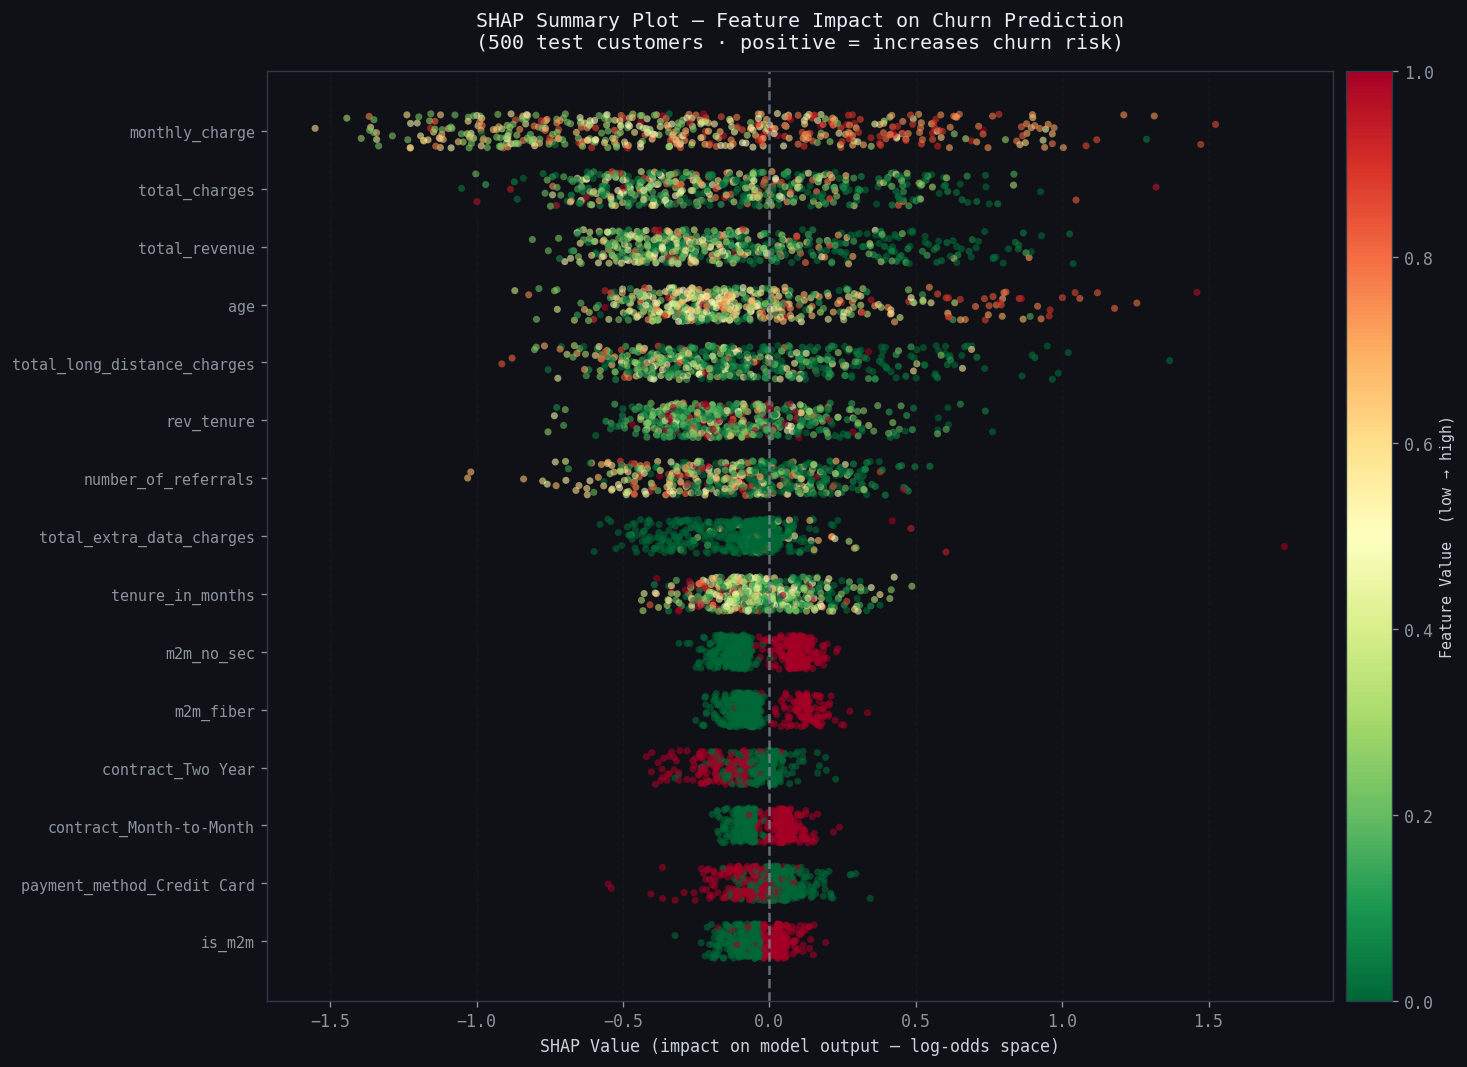


Top 5 features by mean |SHAP|:
  1. monthly_charge                           0.5559
  2. total_charges                            0.3457
  3. total_revenue                            0.3326
  4. age                                      0.2982
  5. total_long_distance_charges              0.2965


In [21]:
print("Computing SHAP for 500 test customers (≈30s)...")

N_SHAP    = 500
idx_shap  = np.random.RandomState(42).choice(len(X_test_t), N_SHAP, replace=False)
shap_matrix = np.zeros((N_SHAP, len(ALL_FEATURES)))

for i, idx in enumerate(idx_shap):
    contribs, _ = compute_shap_contributions(gbm, X_test_t[idx])
    shap_matrix[i] = contribs

# ── Top 15 features by mean |SHAP| ───────────────────────────
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-15:][::-1]
top_features  = [ALL_FEATURES[i] for i in top_idx]
top_shap      = shap_matrix[:, top_idx]
top_x_vals    = X_test_t[idx_shap][:, top_idx]

# ── Beeswarm plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

cmap = plt.cm.RdYlGn_r

for rank, (feat_idx_local, fname) in enumerate(zip(range(len(top_features)), top_features)):
    y_pos    = len(top_features) - rank - 1
    sv       = top_shap[:, feat_idx_local]
    xv       = top_x_vals[:, feat_idx_local]
    
    # Normalize feature values 0-1 for color
    xv_norm = (xv - xv.min()) / (np.ptp(xv) + 1e-9)
    
    # Jitter to avoid overplotting
    jitter   = np.random.RandomState(rank).uniform(-0.3, 0.3, len(sv))
    
    sc = ax.scatter(sv, y_pos + jitter, c=xv_norm, cmap=cmap,
                    s=18, alpha=0.6, linewidths=0)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features[::-1], fontsize=9)
ax.axvline(0, color=MUTED, lw=1.5, linestyle="--", alpha=0.7)
ax.set_xlabel("SHAP Value (impact on model output — log-odds space)", fontsize=10)
ax.set_title(
    "SHAP Summary Plot — Feature Impact on Churn Prediction\n"
    f"({N_SHAP} test customers · positive = increases churn risk)",
    fontsize=12, pad=14)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, orientation="vertical", pad=0.01)
cb.set_label("Feature Value  (low → high)", fontsize=9)
cb.ax.yaxis.label.set_color("#c9d1d9")
cb.ax.tick_params(colors="#8b949e")

ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/05_shap_summary_beeswarm.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("\nTop 5 features by mean |SHAP|:")
for i in range(5):
    print(f"  {i+1}. {top_features[i]:<40} {mean_abs_shap[top_idx[i]]:.4f}")


## 6 · SHAP Waterfall Plot — Why Is THIS Customer Churning?

📋 High-risk customer profile:
   contract                      : Month-to-Month
   internet_type                 : Fiber Optic
   monthly_charge                : 94.45
   tenure_in_months              : 4
   number_of_referrals           : 6
   online_security               : No
   Actual churn                  : 1
   Predicted probability         : 91.1%



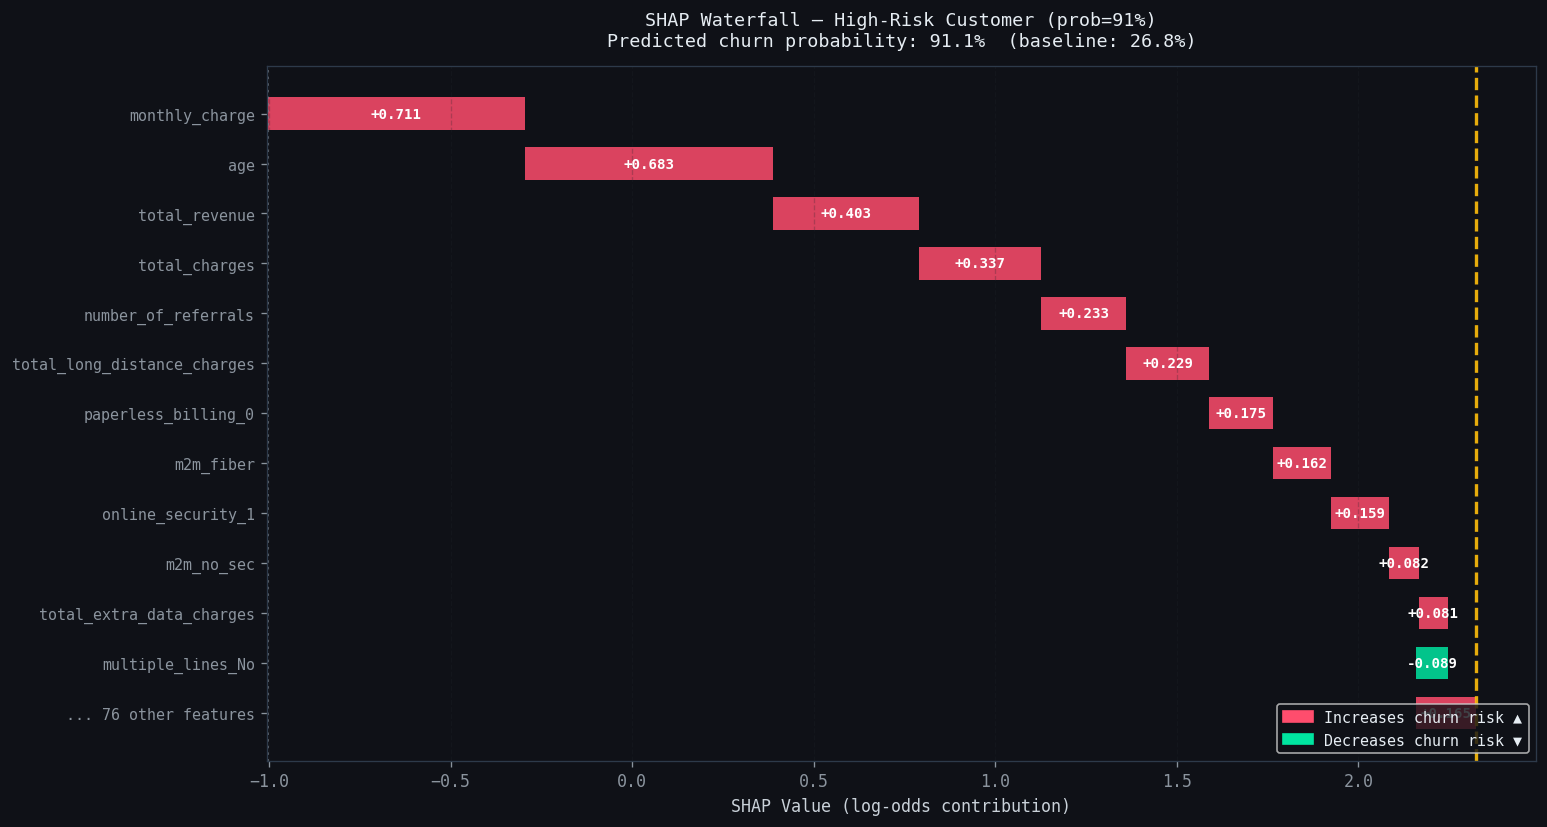

In [22]:
def plot_shap_waterfall(gbm_model, x_t_single, feature_names, all_x_t,
                       customer_label="Customer", top_n=12, 
                       save_path=None, ax_in=None):
    """
    Professional SHAP waterfall chart for a single prediction.
    Shows cumulative contribution from baseline to final prediction.
    """
    from scipy.special import expit
    
    contribs, baseline = compute_shap_contributions(gbm_model, x_t_single)
    final_logodds = baseline + contribs.sum()
    final_prob    = expit(final_logodds)
    
    # Top N by absolute contribution
    top_idx  = np.argsort(np.abs(contribs))[-top_n:][::-1]
    top_idx  = top_idx[np.argsort(contribs[top_idx])[::-1]]  # sort by value
    
    top_feats   = [feature_names[i] for i in top_idx]
    top_contribs = contribs[top_idx]
    
    # Remaining features
    rest_sum = contribs.sum() - top_contribs.sum()
    
    feats_plot    = top_feats + [f"... {len(feature_names)-top_n} other features"]
    contribs_plot = list(top_contribs) + [rest_sum]
    
    # Cumulative for waterfall
    cum  = [baseline]
    for c in contribs_plot:
        cum.append(cum[-1] + c)
    
    if ax_in is None:
        fig, ax = plt.subplots(figsize=(12, 7))
        fig.patch.set_facecolor("#0f1117")
    else:
        ax = ax_in
    
    ax.set_facecolor("#0f1117")
    n = len(feats_plot)
    
    for i, (feat, contrib) in enumerate(zip(feats_plot, contribs_plot)):
        color  = RED if contrib > 0 else GREEN
        bottom = min(cum[i], cum[i+1])
        height = abs(contrib)
        
        bar = ax.barh(n - i - 1, height, left=bottom,
                      color=color, alpha=0.85, height=0.65,
                      edgecolor="none")
        
        # Value label inside bar
        label_x = cum[i] + contrib/2
        ax.text(label_x, n-i-1,
                f"{'+' if contrib>0 else ''}{contrib:.3f}",
                ha="center", va="center", fontsize=8.5,
                color="white", fontweight="bold")
    
    # Baseline + final markers
    ax.axvline(baseline,       color=MUTED,  lw=1.5, linestyle=":", alpha=0.8)
    ax.axvline(cum[-1], color=AMBER, lw=2,   linestyle="--", alpha=0.9)
    
    ax.set_yticks(range(n))
    ax.set_yticklabels(feats_plot[::-1], fontsize=9)
    ax.set_xlabel("SHAP Value (log-odds contribution)", fontsize=10)
    
    ax.set_title(
        f"SHAP Waterfall — {customer_label}\n"
        f"Predicted churn probability: {final_prob:.1%}  "
        f"(baseline: {expit(baseline):.1%})",
        fontsize=11, pad=12)
    
    # Legend
    ax.legend(handles=[
        mpatches.Patch(color=RED,   label="Increases churn risk ▲"),
        mpatches.Patch(color=GREEN, label="Decreases churn risk ▼"),
    ], loc="lower right", fontsize=9)
    
    ax.grid(True, axis="x", alpha=0.25)
    
    if save_path and ax_in is None:
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches="tight", facecolor="#0f1117")
        plt.show()
    
    return final_prob


# ── HIGH RISK example ─────────────────────────────────────────
high_risk_idx = np.where((y_prob >= 0.65) & (y_test.values == 1))[0][:1]
idx_h         = high_risk_idx[0]
customer_info = X_test.iloc[idx_h]

print("📋 High-risk customer profile:")
for col in ["contract","internet_type","monthly_charge","tenure_in_months",
            "number_of_referrals","online_security"]:
    print(f"   {col:<30}: {customer_info[col]}")
print(f"   {'Actual churn':<30}: {y_test.iloc[idx_h]}")
print(f"   {'Predicted probability':<30}: {y_prob[idx_h]:.1%}")
print()

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor("#0f1117")
prob = plot_shap_waterfall(
    gbm, X_test_t[idx_h], ALL_FEATURES, X_test_t,
    customer_label=f"High-Risk Customer (prob={y_prob[idx_h]:.0%})",
    top_n=12, ax_in=ax)
plt.tight_layout()
plt.savefig("../outputs/05_shap_waterfall_high_risk.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()


## 7 · SHAP Force Plot — High Risk vs Low Risk Comparison

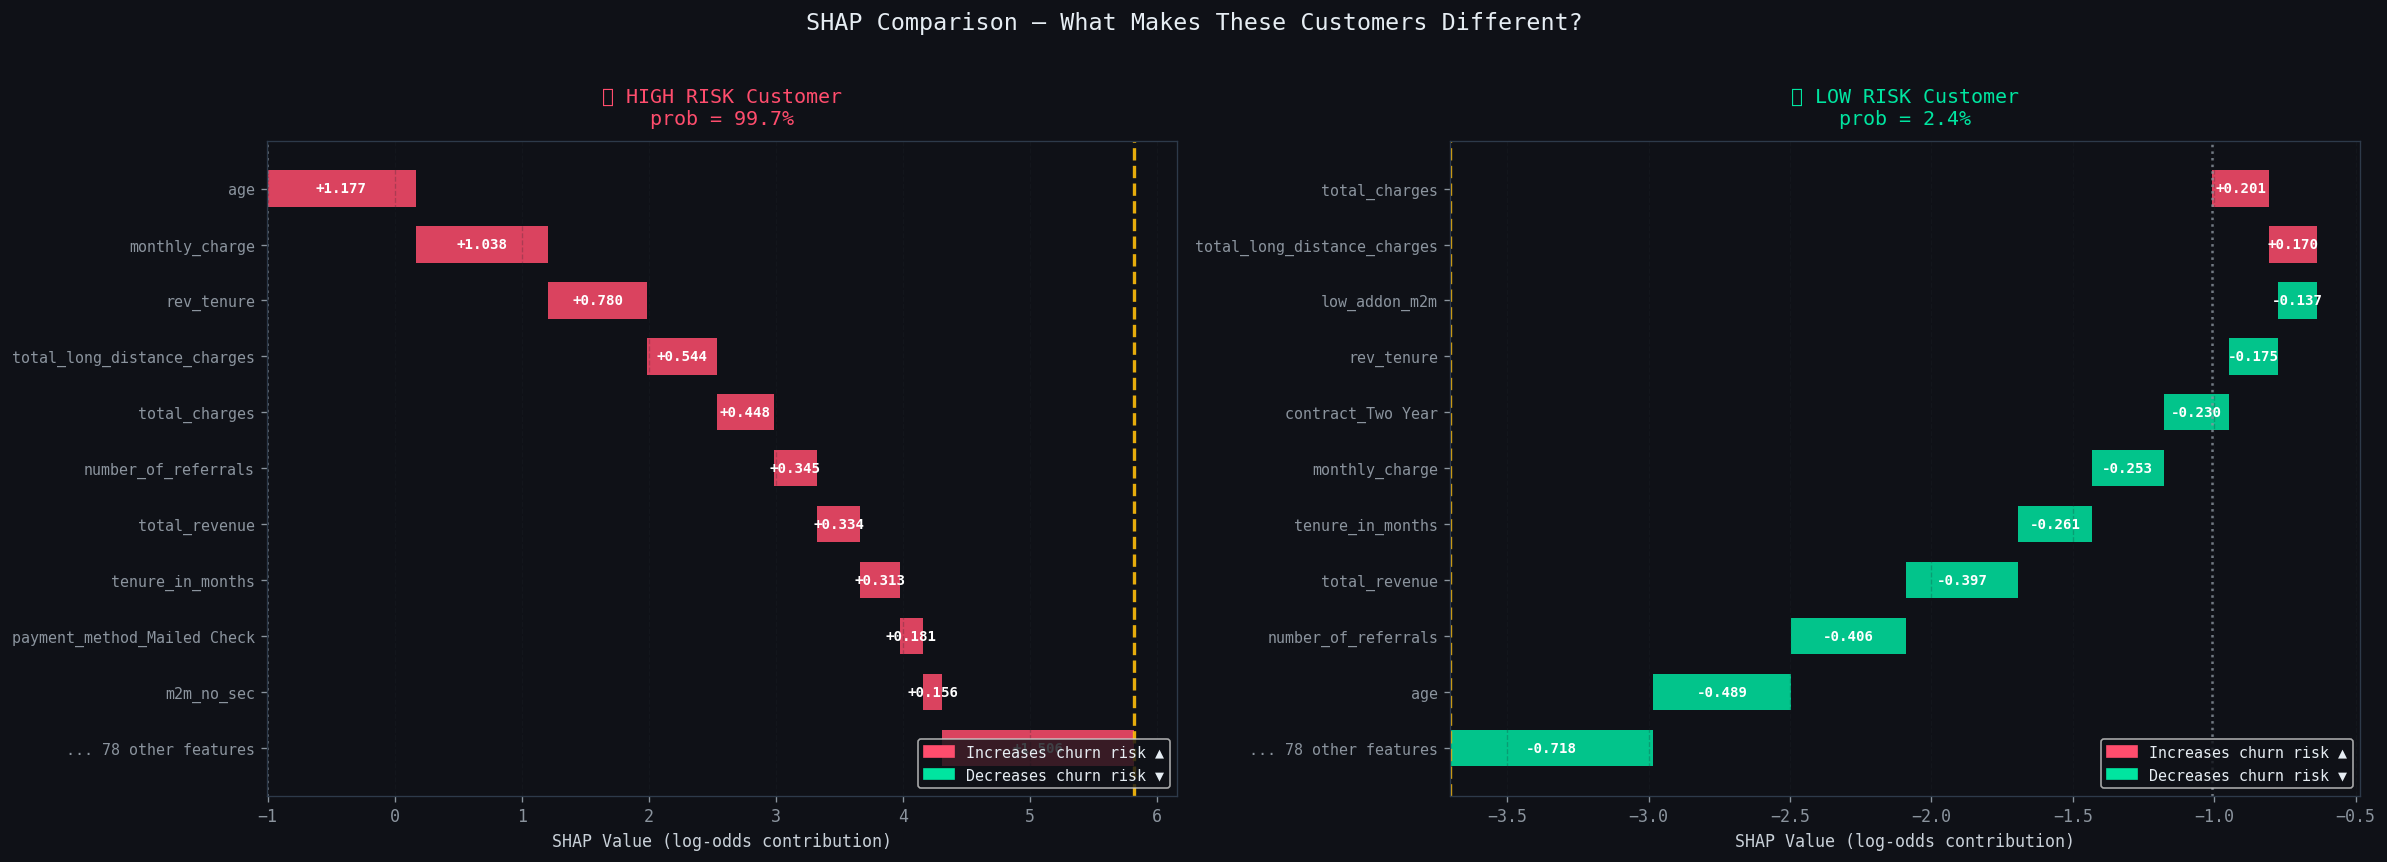

High-risk contract : Month-to-Month
Low-risk  contract : Month-to-Month
High-risk tenure   : 14 months
Low-risk  tenure   : 44 months


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor("#0f1117")

# High risk
high_idx = np.where((y_prob >= 0.65) & (y_test.values == 1))[0][2]
plot_shap_waterfall(gbm, X_test_t[high_idx], ALL_FEATURES, X_test_t,
                    customer_label=f"HIGH RISK (prob={y_prob[high_idx]:.0%})",
                    top_n=10, ax_in=axes[0])
axes[0].set_title(f"🔴 HIGH RISK Customer\nprob = {y_prob[high_idx]:.1%}", 
                  fontsize=12, pad=10, color=RED)

# Low risk
low_idx  = np.where((y_prob <= 0.10) & (y_test.values == 0))[0][2]
plot_shap_waterfall(gbm, X_test_t[low_idx], ALL_FEATURES, X_test_t,
                    customer_label=f"LOW RISK (prob={y_prob[low_idx]:.0%})",
                    top_n=10, ax_in=axes[1])
axes[1].set_title(f"🟢 LOW RISK Customer\nprob = {y_prob[low_idx]:.1%}",
                  fontsize=12, pad=10, color=GREEN)

plt.suptitle("SHAP Comparison — What Makes These Customers Different?",
             fontsize=14, y=1.02, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/05_shap_waterfall_comparison.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"High-risk contract : {X_test.iloc[high_idx]['contract']}")
print(f"Low-risk  contract : {X_test.iloc[low_idx]['contract']}")
print(f"High-risk tenure   : {X_test.iloc[high_idx]['tenure_in_months']:.0f} months")
print(f"Low-risk  tenure   : {X_test.iloc[low_idx]['tenure_in_months']:.0f} months")


## 8 · SHAP Dependence Plot — How Features Interact

Computing SHAP matrix for 800 customers...


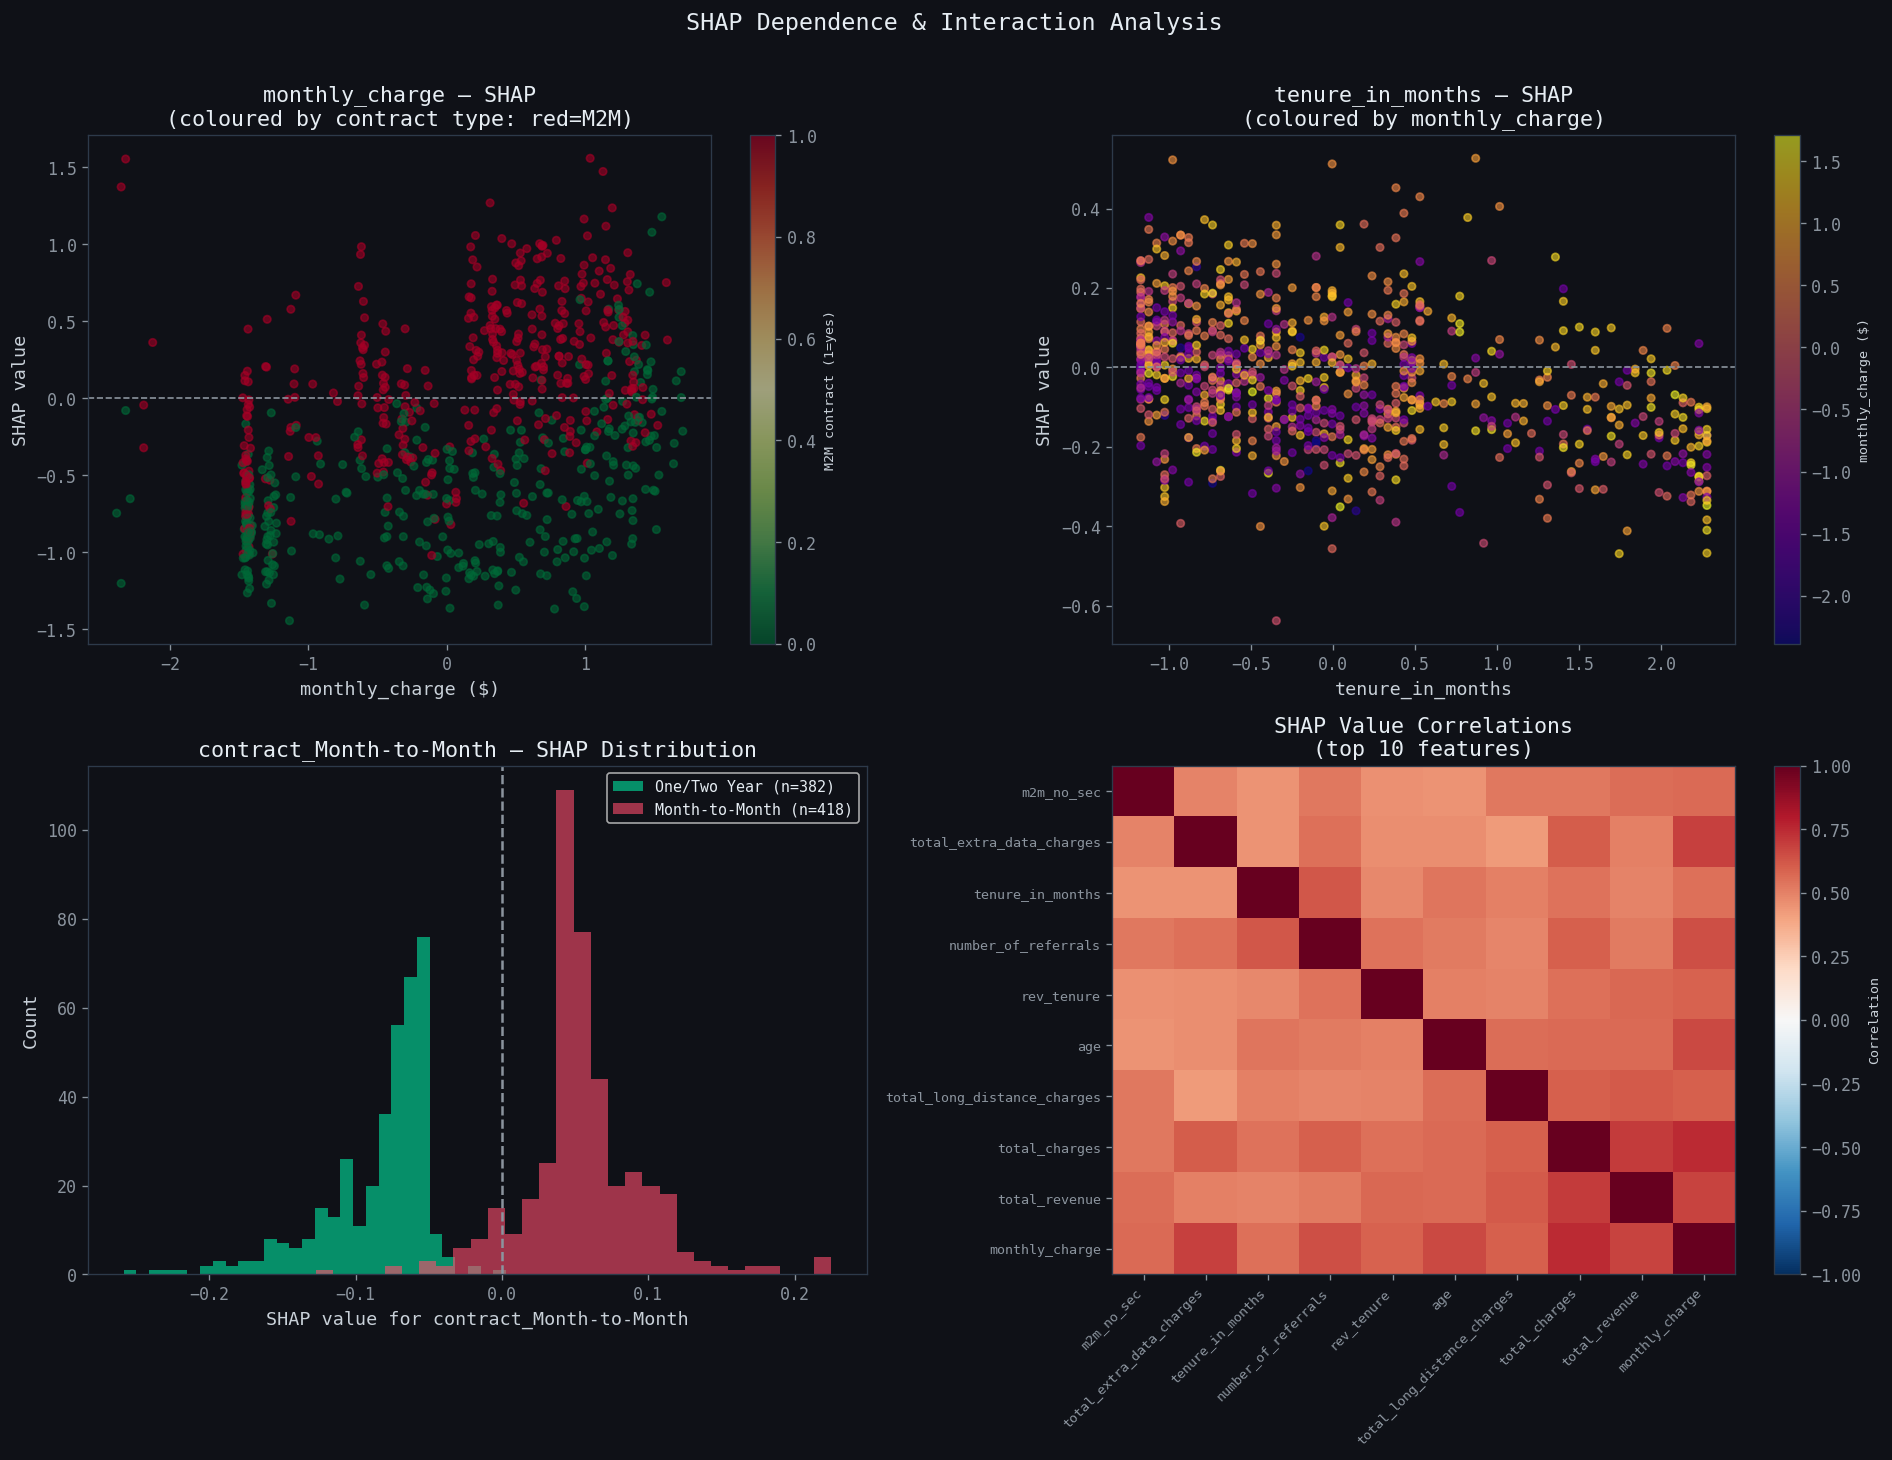

In [24]:
# ── Compute SHAP for 800 samples ─────────────────────────────
print("Computing SHAP matrix for 800 customers...")
N_DEP    = 800
idx_dep  = np.random.RandomState(99).choice(len(X_test_t), N_DEP, replace=False)
shap_dep = np.zeros((N_DEP, len(ALL_FEATURES)))

for i, idx in enumerate(idx_dep):
    contribs, _ = compute_shap_contributions(gbm, X_test_t[idx])
    shap_dep[i] = contribs

X_dep     = X_test_t[idx_dep]
X_dep_raw = X_test.iloc[idx_dep].reset_index(drop=True)

# Feature indices
monthly_idx  = ALL_FEATURES.index("monthly_charge")
tenure_idx   = ALL_FEATURES.index("tenure_in_months")
m2m_idx      = ALL_FEATURES.index("contract_Month-to-Month")
fiber_idx    = ALL_FEATURES.index("internet_type_Fiber Optic")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor("#0f1117")

# Plot 1: monthly_charge SHAP vs monthly_charge value (colored by contract)
ax = axes[0, 0]
m2m_vals = X_dep[:, m2m_idx]
sc = ax.scatter(X_dep[:, monthly_idx], shap_dep[:, monthly_idx],
                c=m2m_vals, cmap="RdYlGn_r", s=20, alpha=0.6)
ax.axhline(0, color=MUTED, lw=1, linestyle="--")
ax.set_xlabel("monthly_charge ($)"); ax.set_ylabel("SHAP value")
ax.set_title("monthly_charge — SHAP\n(coloured by contract type: red=M2M)")
cb = plt.colorbar(sc, ax=ax); cb.set_label("M2M contract (1=yes)", fontsize=8)

# Plot 2: tenure SHAP vs tenure value
ax = axes[0, 1]
sc2 = ax.scatter(X_dep[:, tenure_idx], shap_dep[:, tenure_idx],
                 c=X_dep[:, monthly_idx], cmap="plasma", s=20, alpha=0.6)
ax.axhline(0, color=MUTED, lw=1, linestyle="--")
ax.set_xlabel("tenure_in_months"); ax.set_ylabel("SHAP value")
ax.set_title("tenure_in_months — SHAP\n(coloured by monthly_charge)")
cb2 = plt.colorbar(sc2, ax=ax); cb2.set_label("monthly_charge ($)", fontsize=8)

# Plot 3: M2M contract SHAP distribution
ax = axes[1, 0]
for val, color, label in [(0, GREEN, "One/Two Year"), (1, RED, "Month-to-Month")]:
    mask = m2m_vals == val
    if mask.sum() > 0:
        ax.hist(shap_dep[mask, m2m_idx], bins=30, alpha=0.6,
                color=color, label=f"{label} (n={mask.sum()})", edgecolor="none")
ax.axvline(0, color=MUTED, lw=1.5, linestyle="--")
ax.set_xlabel("SHAP value for contract_Month-to-Month")
ax.set_ylabel("Count")
ax.set_title("contract_Month-to-Month — SHAP Distribution")
ax.legend(fontsize=9)

# Plot 4: Feature interaction heatmap (mean |SHAP| top 10×10)
ax = axes[1, 1]
top10_idx  = np.argsort(np.abs(shap_dep).mean(axis=0))[-10:]
top10_names = [ALL_FEATURES[i] for i in top10_idx]
shap_top10  = shap_dep[:, top10_idx]
corr        = np.corrcoef(shap_top10.T)

im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels([n.replace("contract_","c_").replace("internet_type_","it_")
                     .replace("payment_method_","pm_") for n in top10_names],
                   rotation=45, ha="right", fontsize=8)
ax.set_yticklabels([n.replace("contract_","c_").replace("internet_type_","it_")
                     .replace("payment_method_","pm_") for n in top10_names], fontsize=8)
ax.set_title("SHAP Value Correlations\n(top 10 features)")
plt.colorbar(im, ax=ax).set_label("Correlation", fontsize=8)

plt.suptitle("SHAP Dependence & Interaction Analysis",
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/05_shap_dependence.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()


## 9 · SHAP Profiles by Risk Tier

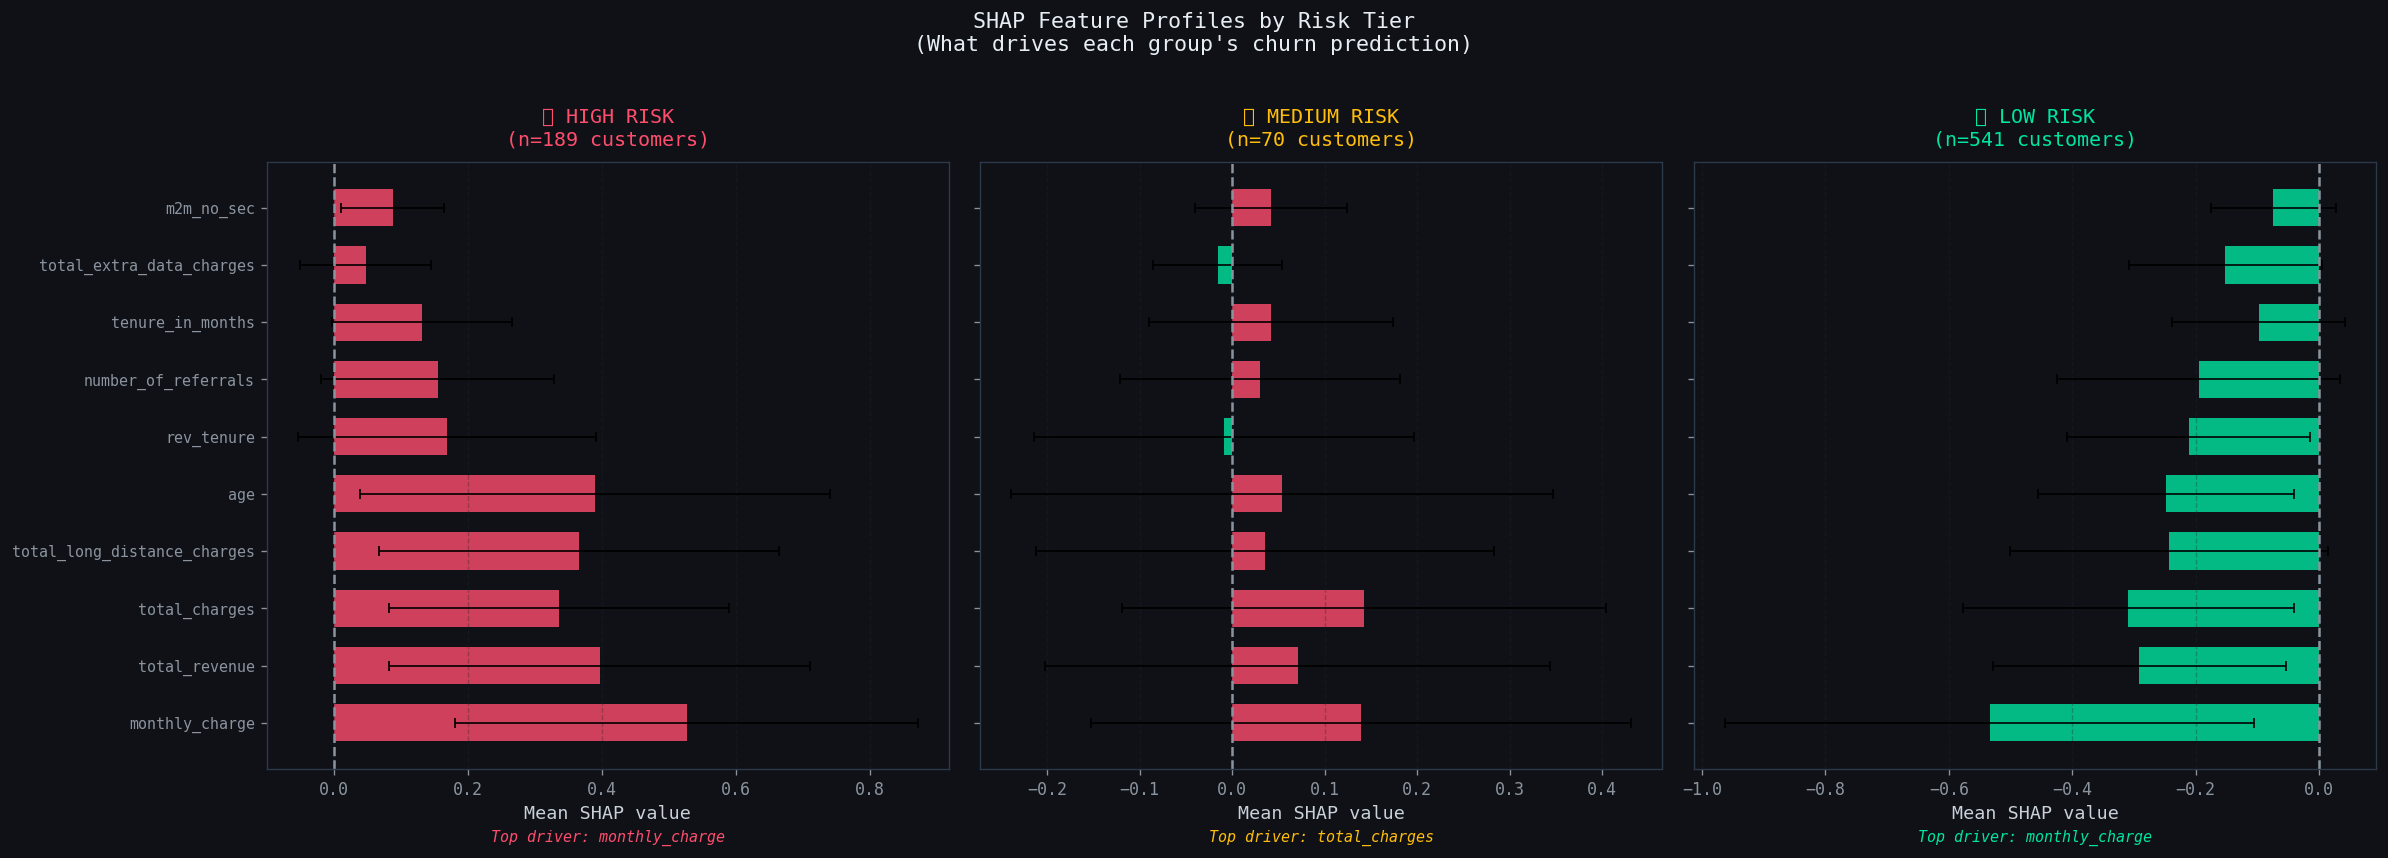

In [25]:
# Assign tiers
tiers = pd.cut(y_prob, bins=[0,.3,.6,1.01], labels=["Low","Medium","High"])
tier_arr = tiers.to_numpy()

# Use shap_dep matrix (800 samples)
tier_dep  = np.array(pd.cut(y_prob[idx_dep], bins=[0,.3,.6,1.01], labels=["Low","Medium","High"]))

# Top 10 features
top10 = np.argsort(np.abs(shap_dep).mean(axis=0))[-10:][::-1]
top10_names = [ALL_FEATURES[i] for i in top10]

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.patch.set_facecolor("#0f1117")

tier_colors = {"High": RED, "Medium": AMBER, "Low": GREEN}
tier_labels = {"High": "🔴 HIGH RISK", "Medium": "🟡 MEDIUM RISK", "Low": "🟢 LOW RISK"}

for ax, tier in zip(axes, ["High","Medium","Low"]):
    mask = tier_dep == tier
    if mask.sum() == 0:
        continue
    
    mean_shap = shap_dep[mask][:, top10].mean(axis=0)
    std_shap  = shap_dep[mask][:, top10].std(axis=0)
    
    colors = [RED if v > 0 else GREEN for v in mean_shap]
    y_pos  = np.arange(len(top10_names))
    
    ax.barh(y_pos, mean_shap, xerr=std_shap, color=colors,
            alpha=0.8, height=0.65, capsize=3, error_kw={"color": MUTED, "lw": 1})
    ax.axvline(0, color=MUTED, lw=1.5, linestyle="--")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top10_names, fontsize=9)
    ax.set_title(f"{tier_labels[tier]}\n(n={mask.sum()} customers)",
                 color=tier_colors[tier], fontsize=12, pad=10)
    ax.set_xlabel("Mean SHAP value")
    ax.grid(True, axis="x", alpha=0.3)
    
    # Annotate top driver
    top_driver = top10_names[np.abs(mean_shap).argmax()]
    ax.text(0.5, -0.12, f"Top driver: {top_driver}",
            transform=ax.transAxes, ha="center", fontsize=9,
            color=tier_colors[tier], style="italic")

plt.suptitle("SHAP Feature Profiles by Risk Tier\n"
             "(What drives each group's churn prediction)",
             fontsize=13, y=1.02, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/05_shap_by_tier.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()


## 10 · Partial Dependence Plots — Feature Effects

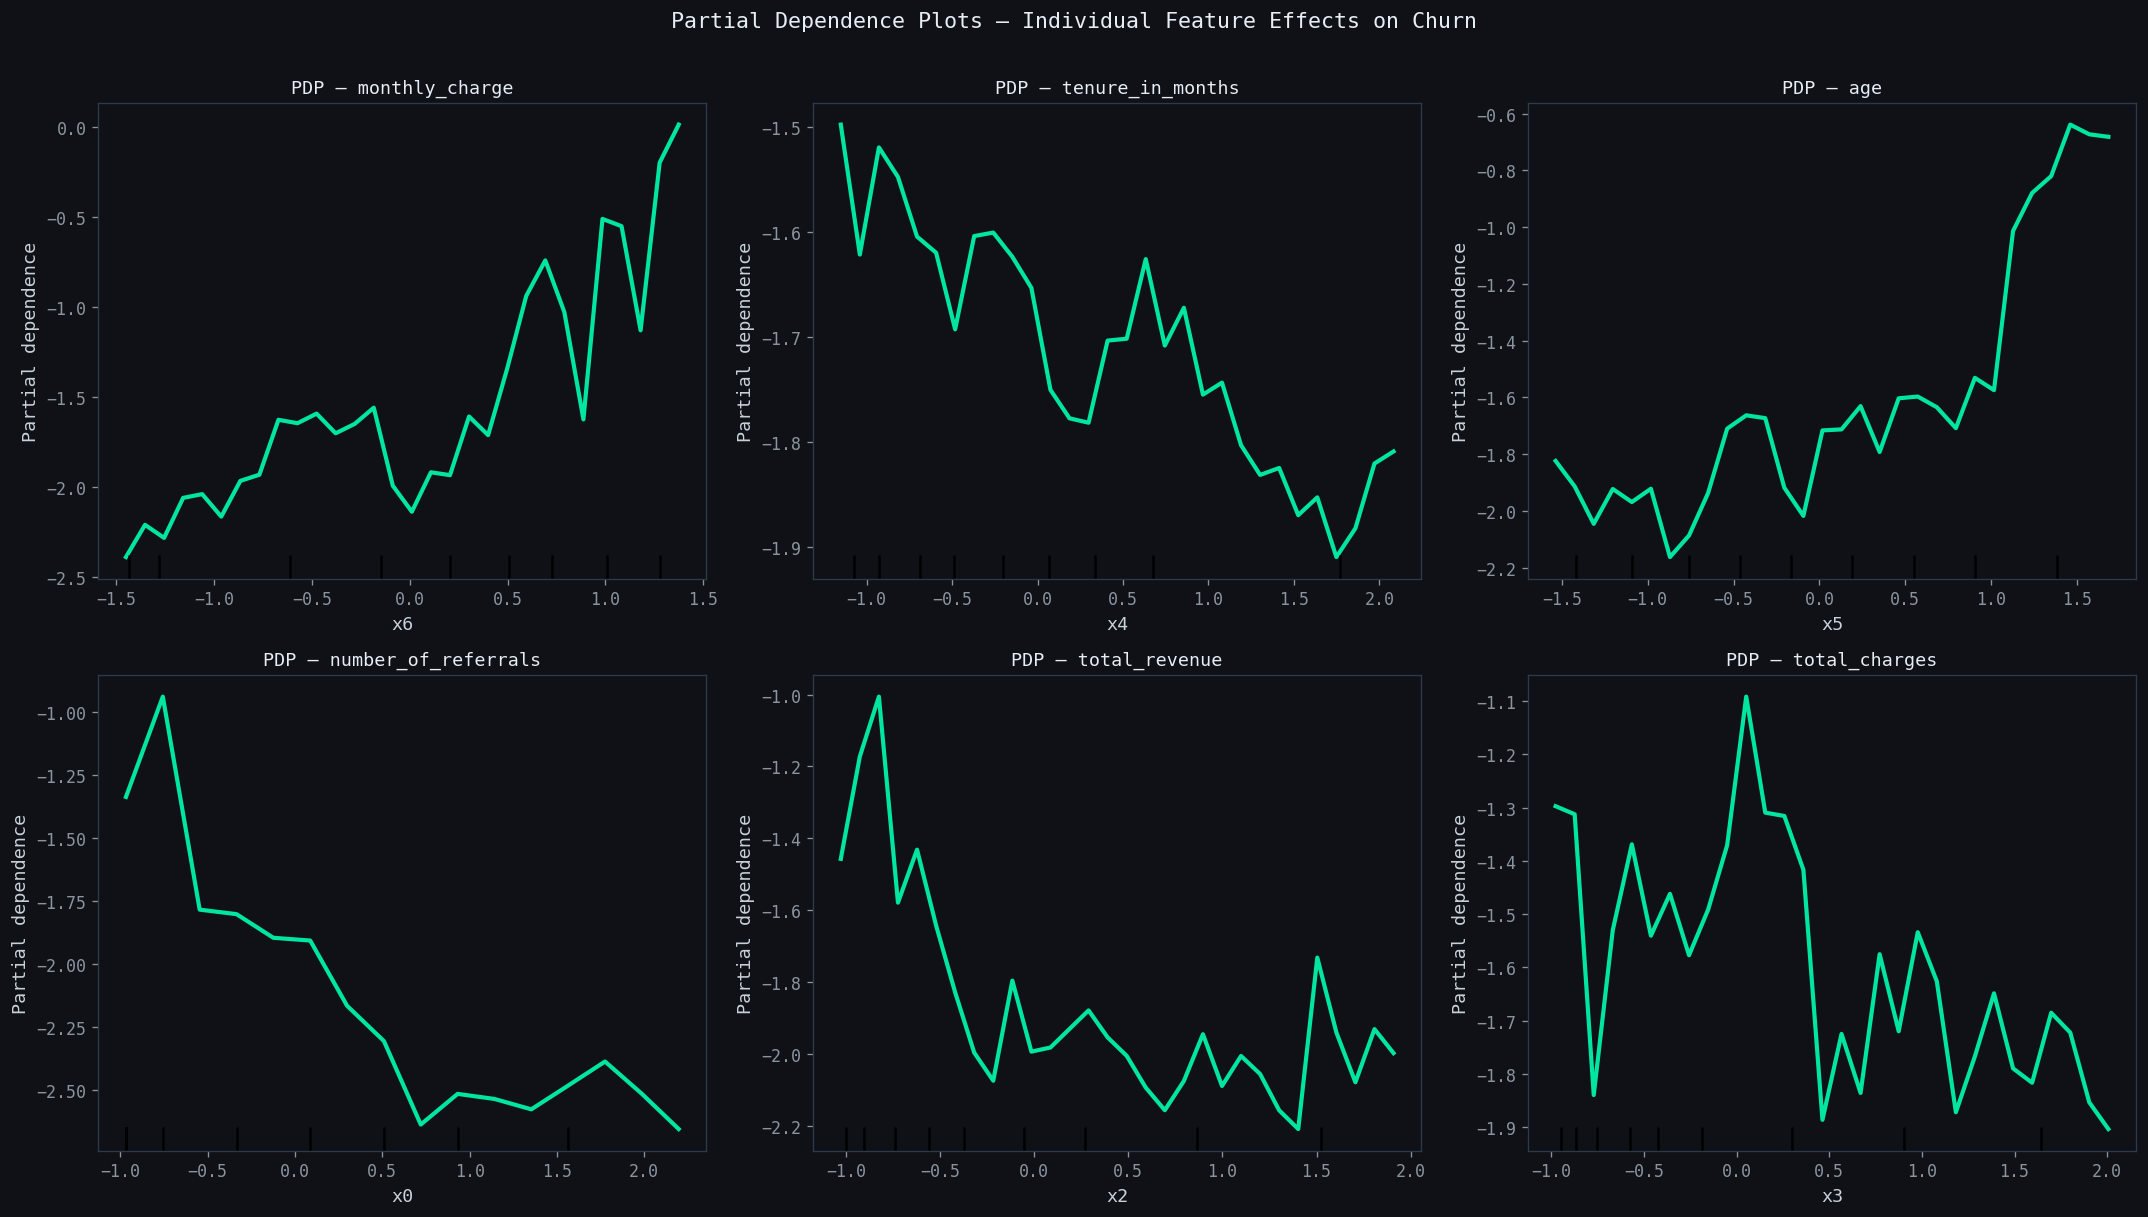

In [26]:
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#0f1117")
axes = axes.flatten()

# Features to plot (by name in transformed space)
feat_pairs = [
    ("monthly_charge",   NUM.index("monthly_charge")),
    ("tenure_in_months", NUM.index("tenure_in_months")),
    ("age",              NUM.index("age")),
    ("number_of_referrals", NUM.index("number_of_referrals")),
    ("total_revenue",    NUM.index("total_revenue")),
    ("total_charges",    NUM.index("total_charges")),
]

for ax, (fname, fidx) in zip(axes, feat_pairs):
    disp = PartialDependenceDisplay.from_estimator(
        gbm, X_test_t[:500], features=[fidx],
        ax=ax, line_kw={"color": GREEN, "lw": 2.5},
        grid_resolution=30)
    
    ax.set_title(f"PDP — {fname}", fontsize=11)
    ax.set_xlabel(fname, fontsize=9)
    ax.set_ylabel("Partial dependence\n(effect on prediction)", fontsize=9)
    ax.axhline(0, color=MUTED, lw=1, linestyle="--", alpha=0.5)
    ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(),
                    alpha=0.1, color=GREEN)

plt.suptitle("Partial Dependence Plots — Individual Feature Effects on Churn",
             fontsize=13, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/05_partial_dependence.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()


## Summary — Key Findings

In [27]:
# Save SHAP matrix for use in webapp
shap_summary = pd.DataFrame(
    np.abs(shap_dep).mean(axis=0).reshape(1, -1),
    columns=ALL_FEATURES
).T.rename(columns={0: "mean_abs_shap"})
shap_summary.index.name = "feature"
shap_summary = shap_summary.sort_values("mean_abs_shap", ascending=False)
shap_summary.to_csv("../outputs/shap_importance.csv")
print("✅ Saved: outputs/shap_importance.csv")

# Print findings
print("\n" + "="*60)
print("  SHAP ANALYSIS — KEY FINDINGS")
print("="*60)
top5 = shap_summary.head(5)
for i, (feat, row) in enumerate(top5.iterrows(), 1):
    direction = "↑ increases" if shap_dep[:, ALL_FEATURES.index(feat)].mean() > 0 else "↓ decreases"
    print(f"  {i}. {feat:<40} {direction} churn risk")

print()
print("  By Risk Tier — top driver:")
for tier in ["High","Medium","Low"]:
    mask    = tier_dep == tier
    top_f   = top10_names[np.abs(shap_dep[mask][:,top10]).mean(axis=0).argmax()]
    print(f"  {tier:<8}: {top_f}")

print()
print("  Saved charts:")
for fname in ["05_roc_pr_curves.png", "05_feature_importance_comparison.png",
              "05_shap_summary_beeswarm.png", "05_shap_waterfall_high_risk.png",
              "05_shap_waterfall_comparison.png", "05_shap_dependence.png",
              "05_shap_by_tier.png", "05_partial_dependence.png"]:
    path = f"../outputs/{fname}"
    exists = os.path.exists(path)
    print(f"  {'✅' if exists else '⬜'} {fname}")


✅ Saved: outputs/shap_importance.csv

  SHAP ANALYSIS — KEY FINDINGS
  1. monthly_charge                           ↓ decreases churn risk
  2. total_revenue                            ↓ decreases churn risk
  3. total_charges                            ↓ decreases churn risk
  4. total_long_distance_charges              ↓ decreases churn risk
  5. age                                      ↓ decreases churn risk

  By Risk Tier — top driver:
  High    : monthly_charge
  Medium  : monthly_charge
  Low     : monthly_charge

  Saved charts:
  ✅ 05_roc_pr_curves.png
  ✅ 05_feature_importance_comparison.png
  ✅ 05_shap_summary_beeswarm.png
  ✅ 05_shap_waterfall_high_risk.png
  ✅ 05_shap_waterfall_comparison.png
  ✅ 05_shap_dependence.png
  ✅ 05_shap_by_tier.png
  ✅ 05_partial_dependence.png
